In [ ]:
import pandas as pd

df = pd.read_sas("LLCP2024.XPT")

print(df.shape)
print(df.columns.tolist())

/tmp/ipykernel_5101/3482463510.py:3: UserWarning: xport file may be corrupted.
  df = pd.read_sas("LLCP2024.XPT")


(7879, 301)
['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTE

In [ ]:
fall_cols = [c for c in df.columns if 'FALL' in c.upper()]
print(fall_cols)

[]


In [ ]:
inj_cols = [c for c in df.columns if 'INJ' in c.upper()]
print(inj_cols)

[]


In [ ]:
mob_cols = [c for c in df.columns if 'WALK' in c.upper()]
print(mob_cols)

['DIFFWALK']


In [ ]:
[c for c in df.columns if 'DIFF' in c.upper()]

['DIFFWALK', 'DIFFDRES', 'DIFFALON', 'CNCRDIFF']

In [ ]:
[c for c in df.columns if 'MOB' in c.upper()]

[]

In [ ]:
[c for c in df.columns if 'BAL' in c.upper()]

[]

In [ ]:
[c for c in df.columns if 'MEM' in c.upper()]

['CIMEMLO1']

In [ ]:
[c for c in df.columns if 'LIMIT' in c.upper()]

[]

In [ ]:
selected_cols = [
    'DIFFWALK', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH',
    'EXERANY2', 'HAVARTH4', 'DIABETE4', 'DEAF', 'BLIND',
    'DECIDE', 'DIFFDRES', 'DIFFALON', '_AGE65YR', '_AGE80',
    '_AGEG5YR', '_BMI5', '_BMI5CAT', '_TOTINDA', '_RFHLTH'
]

df_selected = df[selected_cols].copy()

print(df_selected.shape)
print(df_selected.head())
print(df_selected.isnull().sum())
print(df_selected.describe())

(7879, 20)
   DIFFWALK  SEXVAR  GENHLTH  PHYSHLTH  MENTHLTH  EXERANY2  HAVARTH4  \
0       2.0     2.0      3.0       2.0      88.0       1.0       1.0   
1       2.0     1.0      1.0      88.0      88.0       1.0       1.0   
2       2.0     1.0      2.0      30.0      88.0       1.0       1.0   
3       2.0     1.0      1.0      88.0      88.0       1.0       1.0   
4       1.0     1.0      3.0      88.0      88.0       2.0       2.0   

   DIABETE4  DEAF  BLIND  DECIDE  DIFFDRES  DIFFALON  _AGE65YR  _AGE80  \
0       3.0   2.0    2.0     2.0       2.0       2.0       2.0    78.0   
1       3.0   2.0    2.0     2.0       2.0       2.0       2.0    80.0   
2       3.0   2.0    2.0     2.0       2.0       2.0       1.0    59.0   
3       3.0   1.0    2.0     2.0       2.0       2.0       2.0    80.0   
4       3.0   1.0    2.0     2.0       2.0       1.0       1.0    47.0   

   _AGEG5YR   _BMI5  _BMI5CAT  _TOTINDA  _RFHLTH  
0      12.0  2249.0       2.0       1.0      1.0  
1      13

In [ ]:
import pandas as pd
import numpy as np

df_clean = df_selected.copy()

df_clean = df_clean.replace({
    7: np.nan,
    8: np.nan,
    9: np.nan,
    77: np.nan,
    88: np.nan,
    99: np.nan
})

print(df_clean.isnull().sum())
print(df_clean.describe())

DIFFWALK     286
SEXVAR         0
GENHLTH       20
PHYSHLTH    4928
MENTHLTH    5047
EXERANY2      21
HAVARTH4      41
DIABETE4      12
DEAF         237
BLIND        241
DECIDE       281
DIFFDRES     268
DIFFALON     293
_AGE65YR       0
_AGE80       177
_AGEG5YR    1888
_BMI5        496
_BMI5CAT     496
_TOTINDA      21
_RFHLTH       20
dtype: int64
          DIFFWALK       SEXVAR      GENHLTH     PHYSHLTH     MENTHLTH  \
count  7593.000000  7879.000000  7859.000000  2951.000000  2832.000000   
mean      1.800606     1.560985     2.731009    12.554727    11.828390   
std       0.399571     0.496298     1.062644    11.402362    10.507413   
min       1.000000     1.000000     1.000000     1.000000     1.000000   
25%       2.000000     1.000000     2.000000     2.000000     3.000000   
50%       2.000000     2.000000     3.000000     6.000000     6.000000   
75%       2.000000     2.000000     3.000000    25.000000    20.000000   
max       2.000000     2.000000     5.000000    30.0000

In [ ]:
df_clean.to_csv("fall_risk_analysis_dataset.csv", index=False)

In [ ]:
print(df_clean["DIFFWALK"].value_counts(dropna=False))
print(df_clean["SEXVAR"].value_counts(dropna=False))
print(df_clean["GENHLTH"].value_counts(dropna=False))
print(df_clean["HAVARTH4"].value_counts(dropna=False))
print(df_clean["DIABETE4"].value_counts(dropna=False))

DIFFWALK
2.0    6079
1.0    1514
NaN     286
Name: count, dtype: int64
SEXVAR
2.0    4420
1.0    3459
Name: count, dtype: int64
GENHLTH
3.0    2794
2.0    2293
4.0    1313
1.0    1013
5.0     446
NaN      20
Name: count, dtype: int64
HAVARTH4
2.0    4626
1.0    3212
NaN      41
Name: count, dtype: int64
DIABETE4
3.0    6283
1.0    1296
4.0     222
2.0      66
NaN      12
Name: count, dtype: int64


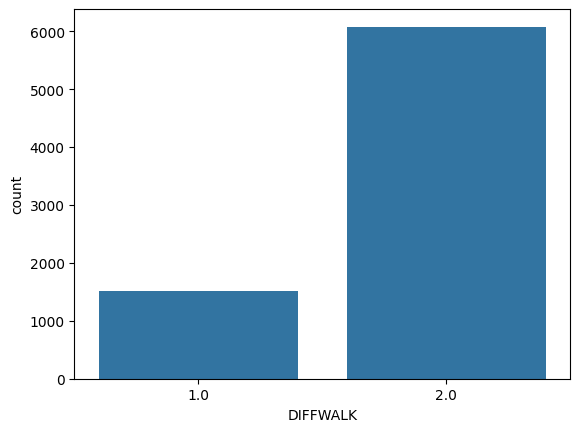

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_clean, x="DIFFWALK")
plt.show()

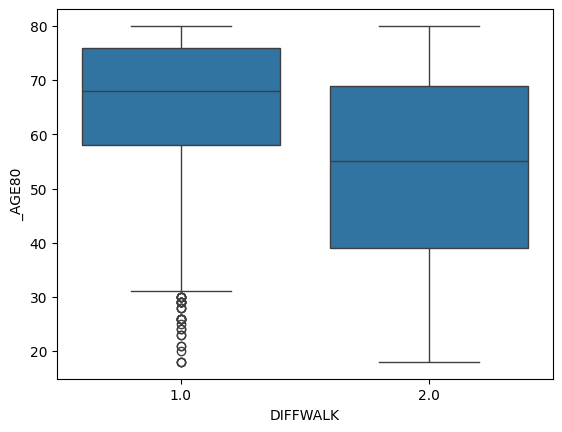

In [ ]:
sns.boxplot(data=df_clean, x="DIFFWALK", y="_AGE80")
plt.show()

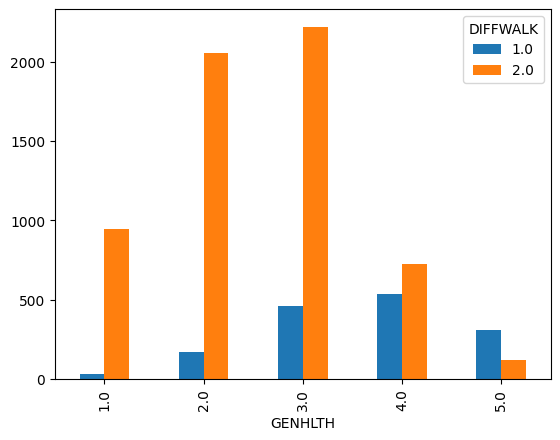

In [ ]:
pd.crosstab(df_clean["GENHLTH"], df_clean["DIFFWALK"]).plot(kind="bar")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df_ml = df_clean.copy()

df_ml["DIFFWALK_TARGET"] = df_ml["DIFFWALK"].map({
    1: 1,
    2: 0
})

In [ ]:
df_ml["DIFFWALK_TARGET"].value_counts()

,count
DIFFWALK_TARGET,
0.0,6079
1.0,1514


In [ ]:
df_clean.head()

,DIFFWALK,SEXVAR,GENHLTH,PHYSHLTH,MENTHLTH,EXERANY2,HAVARTH4,DIABETE4,DEAF,BLIND,DECIDE,DIFFDRES,DIFFALON,_AGE65YR,_AGE80,_AGEG5YR,_BMI5,_BMI5CAT,_TOTINDA,_RFHLTH
0,2.0,2.0,3.0,2.0,NaN,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,78.0,12.0,2249.0,2.0,1.0,1.0
1,2.0,1.0,1.0,NaN,NaN,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,80.0,13.0,2583.0,3.0,1.0,1.0
2,2.0,1.0,2.0,30.0,NaN,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,1.0,59.0,NaN,2253.0,2.0,1.0,1.0
3,2.0,1.0,1.0,NaN,NaN,1.0,1.0,3.0,1.0,2.0,2.0,2.0,2.0,2.0,80.0,13.0,2509.0,3.0,1.0,1.0
4,1.0,1.0,3.0,NaN,NaN,2.0,2.0,3.0,1.0,2.0,2.0,2.0,1.0,1.0,47.0,6.0,1977.0,2.0,2.0,1.0


In [ ]:
df_clean.columns

Index(['DIFFWALK', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'EXERANY2',
       'HAVARTH4', 'DIABETE4', 'DEAF', 'BLIND', 'DECIDE', 'DIFFDRES',
       'DIFFALON', '_AGE65YR', '_AGE80', '_AGEG5YR', '_BMI5', '_BMI5CAT',
       '_TOTINDA', '_RFHLTH'],
      dtype='object')

In [ ]:
df_ml = df_clean.copy()

df_ml["DIFFWALK_TARGET"] = df_ml["DIFFWALK"].map({
    1: 1,
    2: 0
})

In [ ]:
df_ml["DIFFWALK_TARGET"].value_counts(dropna=False)

,count
DIFFWALK_TARGET,
0.0,6079
1.0,1514
NaN,286


In [ ]:
features = [
    "SEXVAR",
    "GENHLTH",
    "PHYSHLTH",
    "MENTHLTH",
    "EXERANY2",
    "HAVARTH4",
    "DIABETE4",
    "DEAF",
    "BLIND",
    "DECIDE",
    "DIFFDRES",
    "DIFFALON",
    "_AGE80",
    "_BMI5",
    "_TOTINDA",
    "_RFHLTH"
]

X = df_ml[features]
y = df_ml["DIFFWALK_TARGET"]

In [ ]:
X.isnull().sum()

,0
SEXVAR,0
GENHLTH,20
PHYSHLTH,4928
MENTHLTH,5047
EXERANY2,21
HAVARTH4,41
DIABETE4,12
DEAF,237
BLIND,241
DECIDE,281


In [ ]:
# Numeric variables
numeric_cols = ["PHYSHLTH", "MENTHLTH", "_AGE80", "_BMI5"]

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Categorical variables
categorical_cols = [
    "SEXVAR",
    "GENHLTH",
    "EXERANY2",
    "HAVARTH4",
    "DIABETE4",
    "DEAF",
    "BLIND",
    "DECIDE",
    "DIFFDRES",
    "DIFFALON",
    "_TOTINDA",
    "_RFHLTH"
]

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

/tmp/ipykernel_5101/2039709345.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].median())
/tmp/ipykernel_5101/2039709345.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].mode()[0])


In [ ]:
X.isnull().sum()

,0
SEXVAR,0
GENHLTH,0
PHYSHLTH,0
MENTHLTH,0
EXERANY2,0
HAVARTH4,0
DIABETE4,0
DEAF,0
BLIND,0
DECIDE,0


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
print(X_encoded.shape)
X_encoded.head()

(7879, 16)


,SEXVAR,GENHLTH,PHYSHLTH,MENTHLTH,EXERANY2,HAVARTH4,DIABETE4,DEAF,BLIND,DECIDE,DIFFDRES,DIFFALON,_AGE80,_BMI5,_TOTINDA,_RFHLTH
0,2.0,3.0,2.0,6.0,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,78.0,2249.0,1.0,1.0
1,1.0,1.0,6.0,6.0,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,80.0,2583.0,1.0,1.0
2,1.0,2.0,30.0,6.0,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,59.0,2253.0,1.0,1.0
3,1.0,1.0,6.0,6.0,1.0,1.0,3.0,1.0,2.0,2.0,2.0,2.0,80.0,2509.0,1.0,1.0
4,1.0,3.0,6.0,6.0,2.0,2.0,3.0,1.0,2.0,2.0,2.0,1.0,47.0,1977.0,2.0,1.0


In [ ]:
y.isnull().sum()

np.int64(286)

In [ ]:
# combine X and y so they stay lined up
ml_data = X.copy()
ml_data["DIFFWALK_TARGET"] = y

# drop rows where the target is missing
ml_data = ml_data.dropna(subset=["DIFFWALK_TARGET"])

# recreate X and y
X = ml_data[features]
y = ml_data["DIFFWALK_TARGET"]

In [ ]:
print(X.isnull().sum())
print(y.isnull().sum())
print(y.value_counts())

SEXVAR      0
GENHLTH     0
PHYSHLTH    0
MENTHLTH    0
EXERANY2    0
HAVARTH4    0
DIABETE4    0
DEAF        0
BLIND       0
DECIDE      0
DIFFDRES    0
DIFFALON    0
_AGE80      0
_BMI5       0
_TOTINDA    0
_RFHLTH     0
dtype: int64
0
DIFFWALK_TARGET
0.0    6079
1.0    1514
Name: count, dtype: int64


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(6074, 16)
(1519, 16)
DIFFWALK_TARGET
0.0    4863
1.0    1211
Name: count, dtype: int64
DIFFWALK_TARGET
0.0    1216
1.0     303
Name: count, dtype: int64


In [ ]:
print(X_encoded.shape)

(7593, 16)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [ ]:
log_pred = log_model.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, log_pred))

print("\nClassification Report")
print(classification_report(y_test, log_pred))

Accuracy: 0.8867676102699145
Precision: 0.8226600985221675
Recall: 0.5511551155115512
F1 Score: 0.6600790513833992

Confusion Matrix
[[1180   36]
 [ 136  167]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93      1216
         1.0       0.82      0.55      0.66       303

    accuracy                           0.89      1519
   macro avg       0.86      0.76      0.80      1519
weighted avg       0.88      0.89      0.88      1519



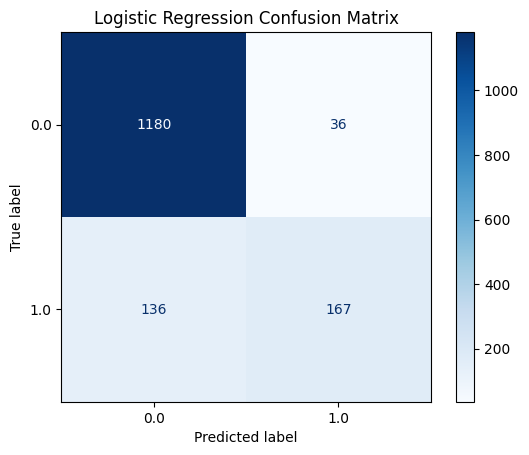

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
tree_pred = tree_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1 Score:", f1_score(y_test, tree_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, tree_pred))

print("\nClassification Report")
print(classification_report(y_test, tree_pred))

Accuracy: 0.858459512837393
Precision: 0.6818181818181818
Recall: 0.5445544554455446
F1 Score: 0.6055045871559633

Confusion Matrix
[[1139   77]
 [ 138  165]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91      1216
         1.0       0.68      0.54      0.61       303

    accuracy                           0.86      1519
   macro avg       0.79      0.74      0.76      1519
weighted avg       0.85      0.86      0.85      1519



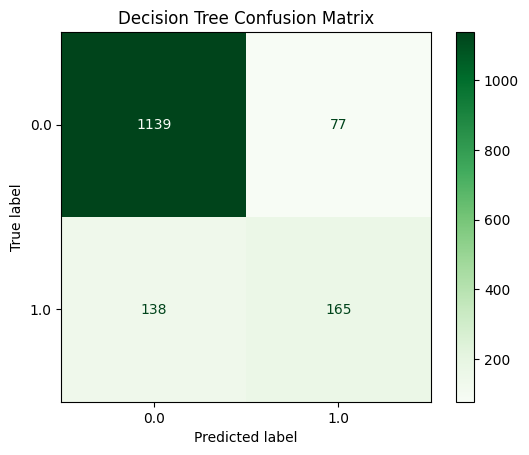

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    tree_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=8
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy: 0.8749177090190915
Precision: 0.8121546961325967
Recall: 0.48514851485148514
F1 Score: 0.6074380165289256

Confusion Matrix
[[1182   34]
 [ 156  147]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.93      1216
         1.0       0.81      0.49      0.61       303

    accuracy                           0.87      1519
   macro avg       0.85      0.73      0.77      1519
weighted avg       0.87      0.87      0.86      1519



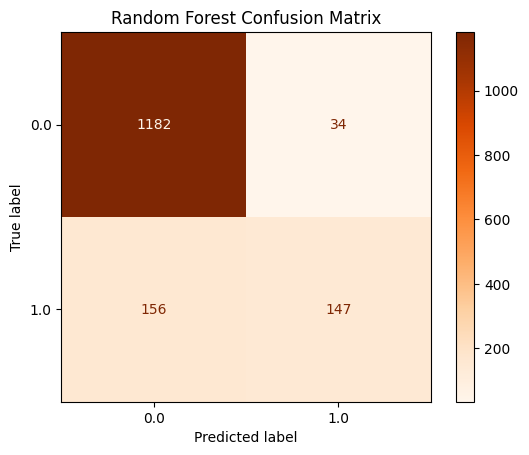

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

     Feature  Importance
2   PHYSHLTH    0.147603
10  DIFFDRES    0.117098
1    GENHLTH    0.115575
12    _AGE80    0.102666
5   HAVARTH4    0.101646
15   _RFHLTH    0.099360
11  DIFFALON    0.093749
13     _BMI5    0.081568
3   MENTHLTH    0.026957
14  _TOTINDA    0.026736
4   EXERANY2    0.024305
6   DIABETE4    0.020019
9     DECIDE    0.011765
8      BLIND    0.011492
0     SEXVAR    0.009824
7       DEAF    0.009633


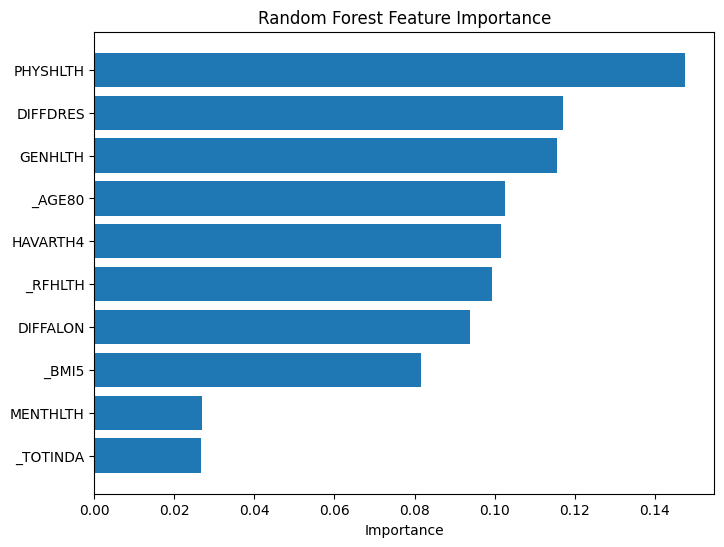

In [ ]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()